In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from src.load_ecg_data import load_ecg_signal
from src.ecg_analysis import detect_r_peaks


# Calculus in Medical Data: Analysis of ECG Signals

Electrocardiography (ECG) records the electrical activity of the heart over time. 
In mathematical terms, ECG data can be interpreted as a function of time.

This project explores how calculus concepts such as derivatives, local extrema, and concavity can be applied to ECG signal analysis.

## Research Questions

This project aims to answer the following questions:

1. What is ECG data and how is it generated?
2. What are the main components of an ECG waveform?
3. How can ECG signals be interpreted as mathematical functions?
4. How does the concept of local extrema relate to ECG peaks?
5. How do convex and concave regions relate to ECG waveform structure?
6. How can algorithms analyze ECG data?

## What is ECG Data?

Electrocardiography (ECG) measures the electrical activity of the heart using electrodes placed on the skin.

Each heartbeat produces a characteristic waveform consisting of several components:

- P wave
- QRS complex
- T wave

These signals are recorded as voltage changes over time and can be analyzed as a time series signal.

## What is ECG Data?

Electrocardiography (ECG) is a medical technique used to record the electrical activity of the heart over time.

The heart generates electrical impulses that cause the heart muscles to contract and pump blood. These electrical signals can be detected using electrodes placed on the skin.

The recorded signal represents voltage changes over time and can be modeled as a one-dimensional function:

$$ECG(t)$$

This makes ECG signals suitable for mathematical analysis using calculus and signal processing techniques.

## Electrical Activity of the Heart

The heart's electrical system controls the rhythm of the heartbeat.

![Heart conduction system](images/heart_conduction_system.jpg)\
Source: https://my.clevelandclinic.org/health/body/21648-heart-conduction-system

The main components involved in generating electrical signals are:

- Sinoatrial (SA) node – the natural pacemaker of the heart
- Atrioventricular (AV) node
- Bundle of His
- Purkinje fibers

These components generate electrical impulses that propagate through the heart muscle and cause contractions.

An ECG records these electrical impulses as a waveform over time.

## Main Components of an ECG Waveform

A typical ECG waveform consists of several characteristic parts:

![ECG waveform](images/ecg_waveform_labeled.jpg)
Source: https://ecgwaves.com/topic/ecg-normal-p-wave-qrs-complex-st-segment-t-wave-j-point/

P wave – represents atrial depolarization  
QRS complex – represents ventricular depolarization  
T wave – represents ventricular repolarization

The QRS complex usually contains the highest peak in the ECG signal and is often used to detect heartbeats.

## Dataset Description

The dataset used in this project contains real electrocardiogram (ECG) recordings stored in EDF (European Data Format).

Files:

r10.edf – contains the ECG signal  
r10.edf.qrs – contains annotations of detected QRS complexes\
r08.edf – contains the ECG signal\  
r08.edf.qrs – contains annotations of detected QRS complexes\
r07.edf – contains the ECG signal\  
r07.edf.qrs – contains annotations of detected QRS complexes\
r04.edf – contains the ECG signal\  
r04.edf.qrs – contains annotations of detected QRS complexes\
r01.edf – contains the ECG signal\  
r01.edf.qrs – contains annotations of detected QRS complexes\

EDF is a standard format used for storing physiological signals such as ECG, EEG, and other biomedical measurements.

This dataset will be used to analyze ECG signals and apply mathematical concepts such as derivatives, local extrema, and concavity.

## ECG as a Mathematical Function

Electrocardiogram (ECG) data can be interpreted as a function of time.

The ECG signal represents electrical potential differences measured at the surface of the body as the heart generates electrical impulses.

Mathematically, we can represent the ECG signal as:

$$ECG(t)$$

where:

$t$ – time  
$ECG(t)$ – electrical signal amplitude measured at time $t$

This means that the ECG signal can be analyzed using mathematical tools from calculus, such as derivatives, local extrema, and curvature.

## The First Derivative of an ECG Signal

The first derivative measures how quickly the ECG signal changes over time.

Mathematically, the derivative is defined as:

$$f'(t) = \frac{d}{dt} \text{ECG}(t)$$

In practical terms, the derivative highlights rapid changes in the signal.

In ECG analysis, the largest changes usually occur during the QRS complex, where the R peak represents the highest point of ventricular depolarization.

Therefore, derivatives are often used in algorithms to detect heartbeats.

## Local Extrema in ECG Signals

A local maximum occurs when a function reaches a peak relative to its neighboring values.

Mathematically, local extrema occur when:

$$f'(t) = 0$$

and the derivative changes sign.

In ECG signals:

• R peaks correspond to local maxima  
• Q and S waves correspond to local minima

Detecting these extrema is essential for identifying heartbeats and calculating heart rate.

In [2]:
signal = load_ecg_signal("data/r10.edf")
print("Signal length:", len(signal))

Signal length: 300000


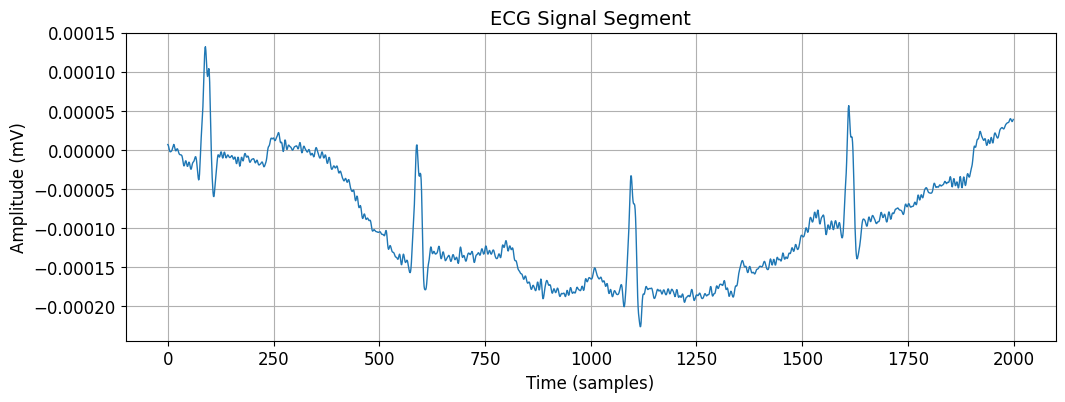

In [ ]:
segment = signal[:2000]
plt.figure()
plt.plot(segment, linewidth=1)
plt.title("ECG Signal Segment")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.rcParams["figure.figsize"] = (12,4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

plt.show()

**Figure 1:** Segment of the ECG signal showing multiple heartbeats.

## Visualization of the ECG Signal

The plot above shows a short segment of the ECG signal.

We can observe several repeating patterns corresponding to individual heartbeats.

Each heartbeat typically includes:

• P wave  
• QRS complex  
• T wave

The R peak represents the highest point of the QRS complex and is commonly used to detect heartbeats.

In [ ]:
signal = load_ecg_signal("data/r10.edf")
peaks = detect_r_peaks(signal)

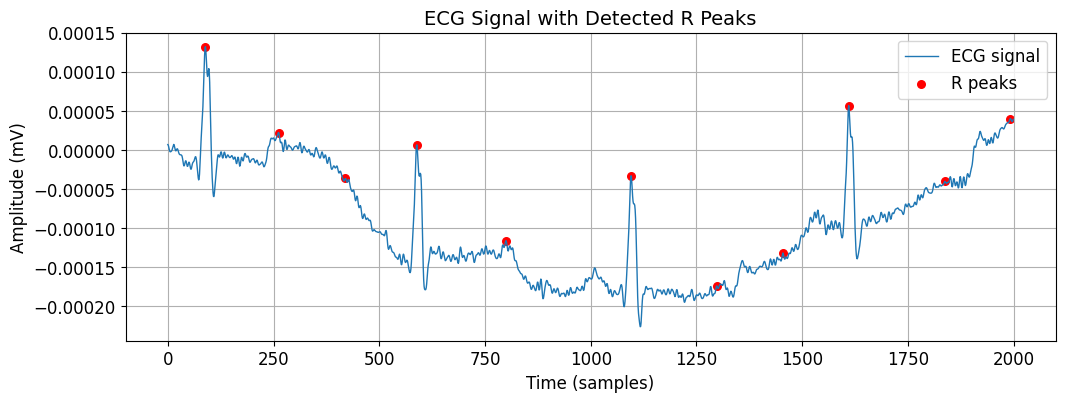

In [ ]:
segment = signal[:2000]
peaks = detect_r_peaks(segment)
plt.rcParams["figure.figsize"] = (12,4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.figure()
plt.plot(segment, label="ECG signal", linewidth=1)
plt.scatter(peaks, segment[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal with Detected R Peaks")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 2:** Detected R peaks corresponding to local maxima of the ECG signal.

R peaks correspond to local maxima in the ECG signal.

## Derivative of the ECG Signal

In calculus, the derivative of a function measures how quickly the function changes.

For a continuous function:

$$ f'(t) = \frac{d}{dt} f(t) $$

However, ECG signals are discrete because they are recorded digitally. Therefore we approximate the derivative using a finite difference:

$$ f'(t) \approx f(t+1) - f(t) $$

This discrete derivative highlights rapid changes in the signal.

In ECG signals, the largest changes typically occur during the **QRS complex**, where ventricular depolarization happens.

In [5]:
import numpy as np

segment = signal[:2000]

derivative = np.diff(segment)

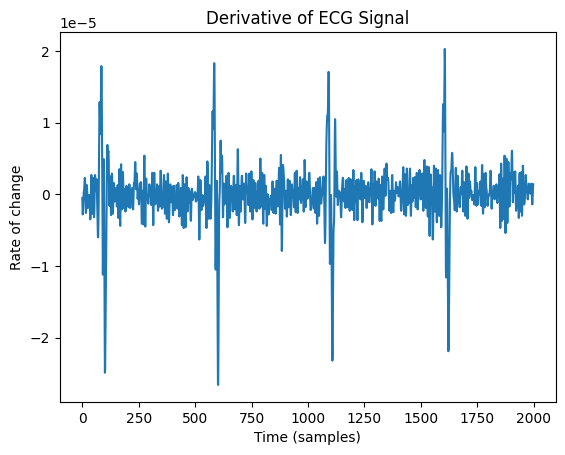

In [4]:
plt.figure()

plt.plot(derivative)

plt.title("Derivative of ECG Signal")

plt.xlabel("Time (samples)")
plt.ylabel("Rate of change")

plt.show()

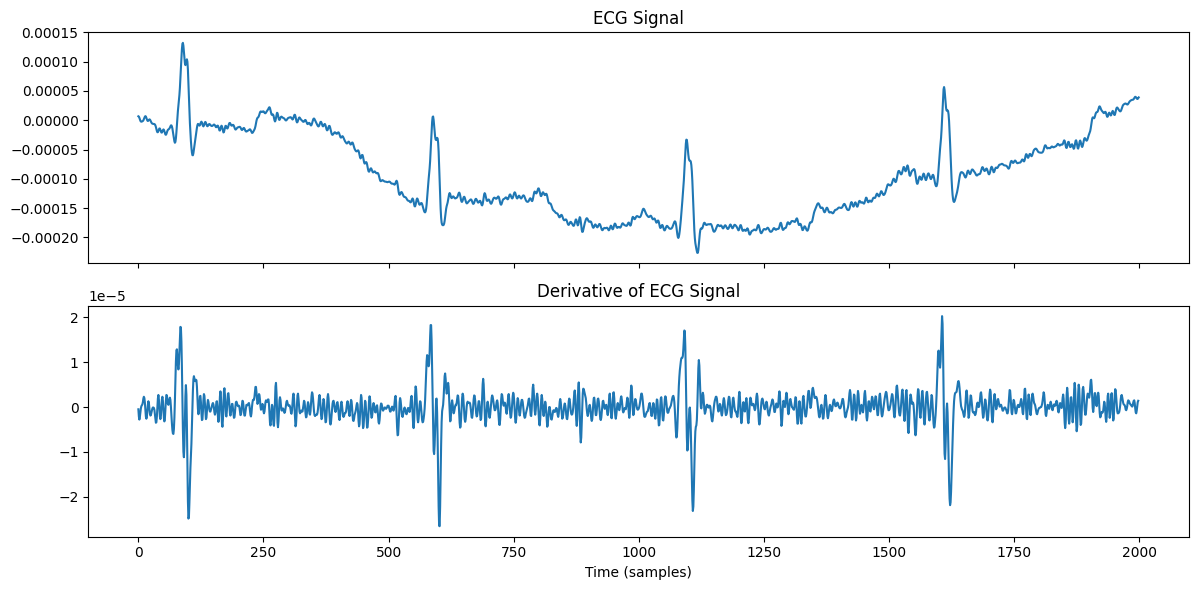

In [6]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(12,6))

axs[0].plot(segment)
axs[0].set_title("ECG Signal")

axs[1].plot(derivative)
axs[1].set_title("Derivative of ECG Signal")

axs[1].set_xlabel("Time (samples)")

plt.tight_layout()

plt.show()

### Interpretation

The first plot shows the original ECG signal.

The second plot shows the derivative of the ECG signal.

Large spikes in the derivative correspond to rapid changes in the signal, which typically occur during the QRS complex.

This demonstrates how calculus can be applied to detect significant features in ECG data.

## Convex and Concave Regions in ECG Signals

The shape of the ECG waveform can also be analyzed using the second derivative.

If the second derivative is positive:

$$ f''(t) > 0 $$

the function is **concave up**.

If the second derivative is negative:

$$ f''(t) < 0 $$

the function is **concave down**.

Changes in concavity correspond to turning points in the ECG waveform and help describe the shape of peaks such as the R wave.